#1- veri setinin çekilmesi ve Gerekli kütüphanelerin indirilmesi

In [3]:
# Gerekli kütüphanelerin kurulumu
!pip install -q transformers datasets torch scikit-learn nltk matplotlib seaborn TurkishStemmer sentencepiece

# Kütüphanelerin içe aktarılması
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os

from datasets import load_dataset
from nltk.corpus import stopwords
from TurkishStemmer import TurkishStemmer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# NLTK gereksinimleri
nltk.download('stopwords')
nltk.download('punkt')

# Uyarıları kapatmak için (W&B vb.)
os.environ["WANDB_DISABLED"] = "true"

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


#2- veri seti temizlenmesi önişleme

In [20]:
def veri_temizleme(metin):
    # 1- Küçük harfe çevirme (Model cased olsa bile tutarlılık sağlar)
    metin = str(metin).lower()

    # 2- Kullanıcı adlarını (@kullanici) temizleme
    metin = re.sub(r'@\w+', '', metin)

    # 3- Web bağlantılarını (http, https, www) temizleme
    metin = re.sub(r'http\S+|www\S+|https\S+', '', metin, flags=re.MULTILINE)

    # 4- Sayıları temizleme (Opsiyonel, duygu analizinde genelde gerekmez)
    metin = re.sub(r'\d+', '', metin)

    # 5- Noktalama işaretlerini ve özel karakterleri temizleme
    metin = re.sub(r'[^a-zçğıöşü\s]', '', metin)

    # 6- Gereksiz boşlukları (fazladan boşluk, tab, yeni satır) temizleme
    metin = re.sub(r'\s+', ' ', metin).strip()

    # Stopwords ve Stemming işlemlerini bilerek yapmıyoruz.
    return metin

print("Temizleme fonksiyonu hazır.")

Temizleme fonksiyonu hazır.


#3- veri yükleme ve inceleme

In [21]:
# Veri setini indir
dataset = load_dataset("yassiracharki/Yelp_Reviews_for_Binary_Senti_Analysis")
df = dataset['train'].to_pandas()

# Örneklem al
df = df.sample(n=15000, random_state=42).reset_index(drop=True)

# İlk 5 satırı göster (Sütun isimleri: 'class_index' ve 'review_text')
print("\n--- İlk 5 Satır (Ham Veri) ---")
display(df.head())

# Temizleme işlemini uygula
print("\nVeriler temizleniyor...")
df['clean_text'] = df['review_text'].apply(veri_temizleme)
print("Temizleme tamamlandı!")

# Sütun adını 'class_index'ten 'label'a çevirelim
# (Not: Bu veri setinde 1: Negatif, 2: Pozitif şeklindedir)
df = df.rename(columns={'class_index': 'label'})

# Etiketleri 0'dan başlayacak şekilde düzeltelim (Transformers 0 ve 1 bekler)
# 1 ve 2 olan değerleri 0 ve 1 yapıyoruz
df['label'] = df['label'] - 1

print("Sütun isimleri ve etiket değerleri güncellendi.")


--- İlk 5 Satır (Ham Veri) ---


,class_index,review_text
0,2,This place is one of my favorite comic shops. ...
1,1,The wait time for an appointment is ridiculous...
2,1,I did not like this hotel at all. It's very ol...
3,2,Mill Avenue has a serious issue with parking. ...
4,2,Favorite sushi place in NV! Price is reasonab...



Veriler temizleniyor...
Temizleme tamamlandı!
Sütun isimleri ve etiket değerleri güncellendi.


## 4- sınıf dağılımını görselleştirme

/tmp/ipython-input-2526845243.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette='viridis')


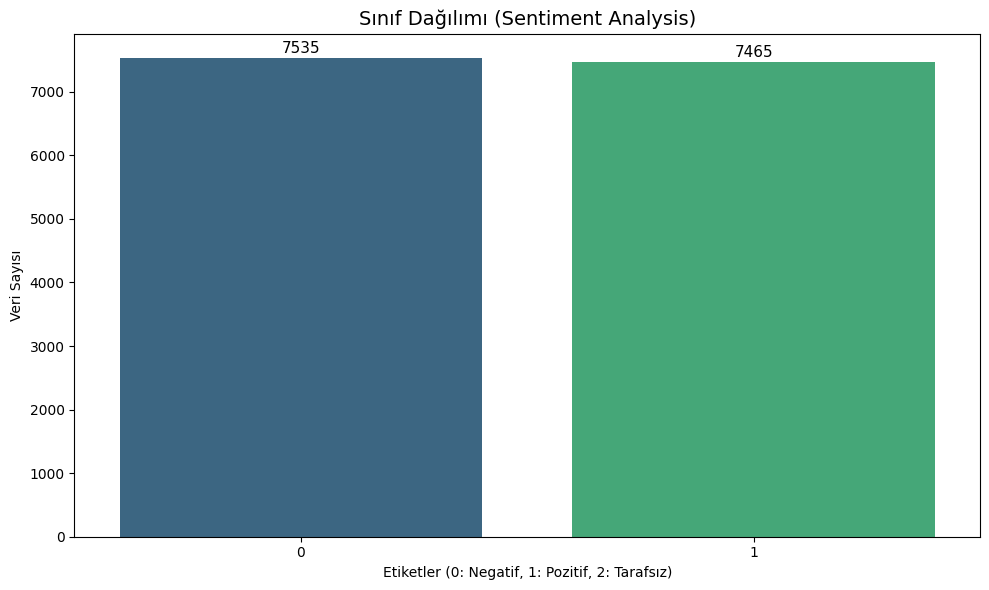

In [22]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='label', data=df, palette='viridis')

plt.title('Sınıf Dağılımı (Sentiment Analysis)', fontsize=14)
plt.ylabel('Veri Sayısı')
plt.xlabel('Etiketler (0: Negatif, 1: Pozitif, 2: Tarafsız)')

# Çubukların üzerine sayıları yazdırma
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 7),
                textcoords='offset points',
                fontsize=11)

plt.tight_layout()
plt.show()

#5- tekrar önişleme aşaması

In [24]:
# 5- Veri Hazırlama, Bölme ve Dataset Tanımlama

# 1. Adım: Boş Veri Kontrolü
# Temizleme işleminden sonra bazı satırlar tamamen boşalmış olabilir, bunları temizleyelim.
df = df.dropna(subset=['clean_text'])
df = df[df['clean_text'].str.strip() != ""]

# 2. Adım: Etiketleri Sayısala Çevirme (Label Encoding)
# Sütun adını 'label' yapmıştık, buradan devam ediyoruz.
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

# Sınıf eşleşmelerini saklayalım (Sonuçları yorumlarken lazım olacak)
label_map = dict(zip(le.transform(le.classes_), le.classes_))
print(f"Sınıf Haritası: {label_map}")
num_labels = len(le.classes_)

# 3. Adım: Eğitim ve Test Olarak Bölme
# Stratify=y ekleyerek sınıfların her iki kümede de dengeli dağılmasını sağlıyoruz.
X = df['clean_text'].values.tolist()
y = df['label_id'].values.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Sınıf dağılımını korur
)

print(f"Eğitim Verisi: {len(X_train)}")
print(f"Test Verisi  : {len(X_test)}")

# 4. Adım: PyTorch Dataset Sınıfı
# Hugging Face Trainer'ın beklediği formatta veri sağlar.
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# 5. Adım: Metrik Fonksiyonu
# Modelin başarısını ölçmek için her değerlendirme adımında çağrılır.
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Çoklu sınıf (0, 1, 2) olduğu için 'weighted' ortalama en sağlıklısıdır.
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

print("\nVeri hazırlama ve Dataset sınıfı hazır.")

Sınıf Haritası: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
Eğitim Verisi: 12000
Test Verisi  : 3000

Veri hazırlama ve Dataset sınıfı hazır.


#6- transformer modelleri

##6.1- BERTurk

In [31]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

# 1. Model ve Tokenizer Seçimi
# NOT: Veri setiniz İngilizce ise 'bert-base-uncased' kullanmanızı öneririm.
model_adi_bert = "dbmdz/bert-base-turkish-cased"
print(f"\n>>> {model_adi_bert} Hazırlanıyor...")

tokenizer_bert = AutoTokenizer.from_pretrained(model_adi_bert)

# 2. Veriyi Tokenize Etme
print("Veriler tokenize ediliyor...")
train_enc_bert = tokenizer_bert(X_train, truncation=True, padding='max_length', max_length=256)
test_enc_bert = tokenizer_bert(X_test, truncation=True, padding='max_length', max_length=256)

# 3. Dataset Nesnelerini Oluşturma (5. blokta tanımlanan sınıfı kullanır)
train_dataset_bert = SentimentDataset(train_enc_bert, y_train)
test_dataset_bert = SentimentDataset(test_enc_bert, y_test)

# 4. Modeli Yükleme
model_bert = AutoModelForSequenceClassification.from_pretrained(
    model_adi_bert,
    num_labels=num_labels # Yelp için 2, Türkçe veri seti için 3 olacaktır
)

# 5. Eğitim Argümanları (Performans için güncellendi)
training_args_bert = TrainingArguments(
    output_dir='./results_bert',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

# 6. Trainer Tanımlama
trainer_bert = Trainer(
    model=model_bert,
    args=training_args_bert,
    train_dataset=train_dataset_bert,
    eval_dataset=test_dataset_bert,
    compute_metrics=compute_metrics,
)

# 7. Eğitimi Başlatma
print("\nBERTurk Eğitimi Başlıyor...\n" + "-"*30)
trainer_bert.train()

# 8. Değerlendirme ve Sonuçlar
print("\n" + "-"*30 + "\nBERTurk Değerlendirme Sonuçları:")
results_bert = trainer_bert.evaluate()

for key, value in results_bert.items():
    print(f"{key}: {value:.4f}")

# Kaydetme
model_bert.save_pretrained("./best_bert_model")
tokenizer_bert.save_pretrained("./best_bert_model")


>>> dbmdz/bert-base-turkish-cased Hazırlanıyor...
Veriler tokenize ediliyor...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).



BERTurk Eğitimi Başlıyor...
------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.357400,0.384677,0.833000,0.830957,0.850847,0.833000


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.357400,0.384677,0.833000,0.830957,0.850847,0.833000
2,0.275700,0.346756,0.864000,0.863412,0.870939,0.864000
3,0.218700,0.353085,0.879667,0.879577,0.881041,0.879667



------------------------------
BERTurk Değerlendirme Sonuçları:


eval_loss: 0.3531
eval_accuracy: 0.8797
eval_f1: 0.8796
eval_precision: 0.8810
eval_recall: 0.8797
eval_runtime: 40.3674
eval_samples_per_second: 74.3170
eval_steps_per_second: 4.6570
epoch: 3.0000


('./best_bert_model/tokenizer_config.json',
 './best_bert_model/special_tokens_map.json',
 './best_bert_model/vocab.txt',
 './best_bert_model/added_tokens.json',
 './best_bert_model/tokenizer.json')

##6.2- XLM-RoBERTa

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

# 1. Model ve Tokenizer Seçimi
# XLM-RoBERTa çok dilli olduğu için hem İngilizce (Yelp) hem Türkçe veride iyi çalışır.
model_adi_xlm = "xlm-roberta-base"
print(f"\n>>> {model_adi_xlm} Hazırlanıyor...")

tokenizer_xlm = AutoTokenizer.from_pretrained(model_adi_xlm)

# 2. Veriyi Tokenize Etme
train_enc_xlm = tokenizer_xlm(X_train, truncation=True, padding='max_length', max_length=256)
test_enc_xlm = tokenizer_xlm(X_test, truncation=True, padding='max_length', max_length=256)

# 3. Dataset Nesnelerini Oluşturma
train_dataset_xlm = SentimentDataset(train_enc_xlm, y_train)
test_dataset_xlm = SentimentDataset(test_enc_xlm, y_test)

# 4. Modeli Yükleme
model_xlm = AutoModelForSequenceClassification.from_pretrained(
    model_adi_xlm,
    num_labels=num_labels  # Yelp verisi için 2 olmalı
)

# 5. Eğitim Argümanları
# aynı parametreleri kulladık
training_args_xlm = TrainingArguments(
    output_dir='./results_xlm',
    num_train_epochs=3,              # 1 yerine 3 yaparak başarımı artırıyoruz
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=2e-5,              # Fine-tuning için en stabil oran
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",      # En iyi modeli F1 skoruna göre kaydet
)

# 6. Trainer Tanımlama
trainer_xlm = Trainer(
    model=model_xlm,
    args=training_args_xlm,
    train_dataset=train_dataset_xlm,
    eval_dataset=test_dataset_xlm,
    compute_metrics=compute_metrics,
)

# 7. Eğitimi Başlatma
print("\nXLM-RoBERTa Eğitimi Başlıyor...\n" + "-"*30)
trainer_xlm.train()

# 8. Değerlendirme ve Sonuçlar
print("\n" + "-"*30 + "\nXLM-RoBERTa Değerlendirme Sonuçları:")
results_xlm = trainer_xlm.evaluate()

for key, value in results_xlm.items():
    print(f"{key}: {value:.4f}")

# Modeli ve Tokenizer'ı kaydetme
model_xlm.save_pretrained("./best_xlm_model")
tokenizer_xlm.save_pretrained("./best_xlm_model")


>>> xlm-roberta-base Hazırlanıyor...


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).



XLM-RoBERTa Eğitimi Başlıyor...
------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.256700,0.213070,0.933000,0.932982,0.933638,0.933000


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.256700,0.213070,0.933000,0.932982,0.933638,0.933000
2,0.169200,0.218224,0.940667,0.940650,0.941337,0.940667


#6- Görselleştirme



##6.1- Confusion Matrix



BERTurk (Model 1) tahminleri alınıyor...


XLM-RoBERTa (Model 2) tahminleri alınıyor...


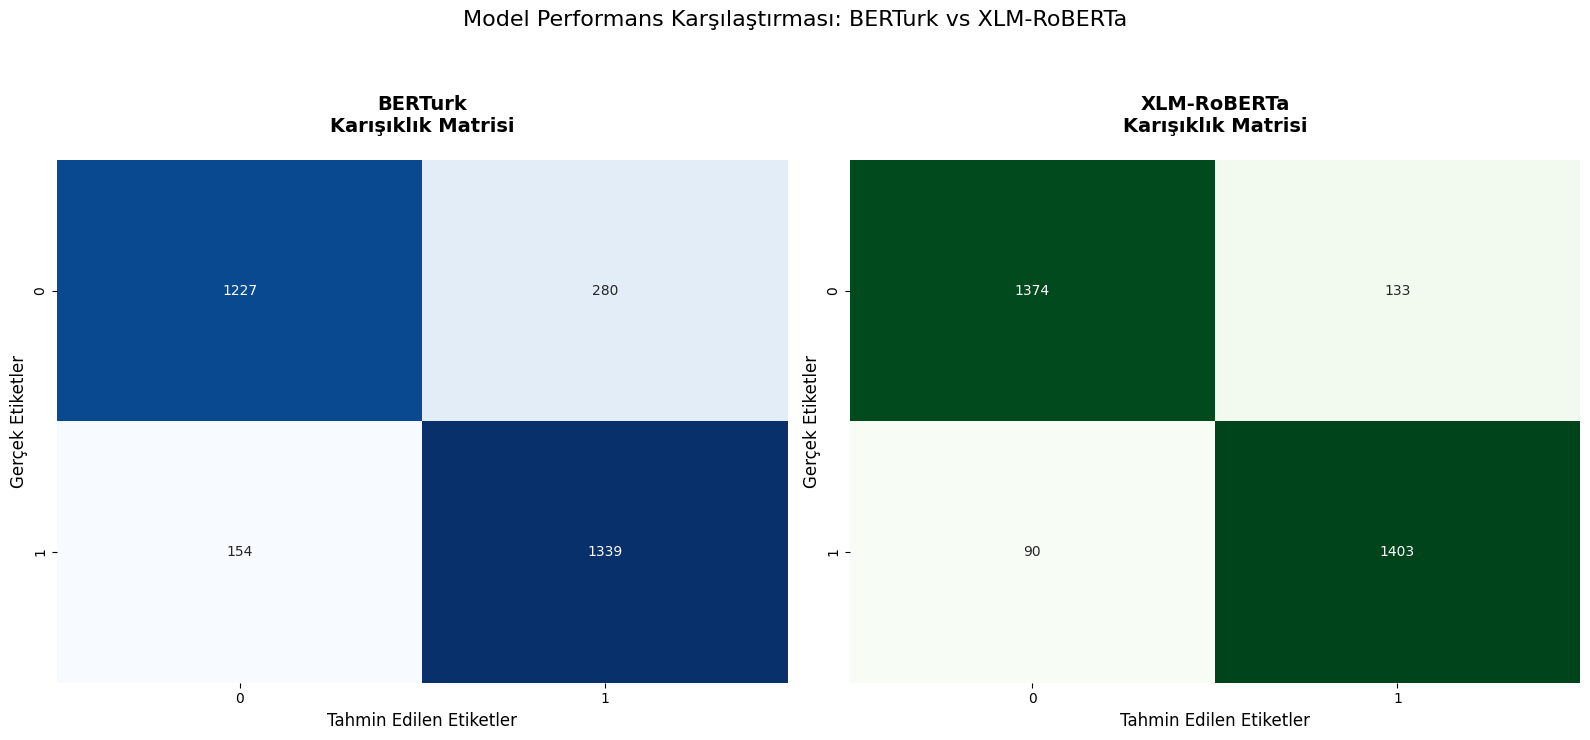

In [27]:
# --- 1. Tahminleri Alma ---

# BERTurk Tahminleri
print("BERTurk (Model 1) tahminleri alınıyor...")
preds_bert_output = trainer_bert.predict(test_dataset_bert)
y_pred_bert = preds_bert_output.predictions.argmax(-1)

# XLM-RoBERTa Tahminleri
print("XLM-RoBERTa (Model 2) tahminleri alınıyor...")
preds_xlm_output = trainer_xlm.predict(test_dataset_xlm)
y_pred_xlm = preds_xlm_output.predictions.argmax(-1)

# --- 2. Matrisleri Hesaplama ---
# y_test: Gerçek etiketler
cm_bert = confusion_matrix(y_test, y_pred_bert)
cm_xlm = confusion_matrix(y_test, y_pred_xlm)

# --- 3. Görselleştirme (Yan Yana) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Sınıf İsimleri (Eğer le.classes_ [0, 1] ise daha anlaşılır isimler verebilirsiniz)
# Örnek: class_names = ['Negatif', 'Pozitif']
class_names = le.classes_

# Grafik 1: BERTurk
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[0], cbar=False) # Renk çubuğunu temizlik için kaldırdık
axes[0].set_title('BERTurk\nKarışıklık Matrisi', fontsize=14, fontweight='bold', pad=20)
axes[0].set_ylabel('Gerçek Etiketler', fontsize=12)
axes[0].set_xlabel('Tahmin Edilen Etiketler', fontsize=12)

# Grafik 2: XLM-RoBERTa
sns.heatmap(cm_xlm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[1], cbar=False)
axes[1].set_title('XLM-RoBERTa\nKarışıklık Matrisi', fontsize=14, fontweight='bold', pad=20)
axes[1].set_ylabel('Gerçek Etiketler', fontsize=12)
axes[1].set_xlabel('Tahmin Edilen Etiketler', fontsize=12)

# Genel başlık ekleyelim
plt.suptitle('Model Performans Karşılaştırması: BERTurk vs XLM-RoBERTa', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

##6.2- Performans karşılaştırma grafiği

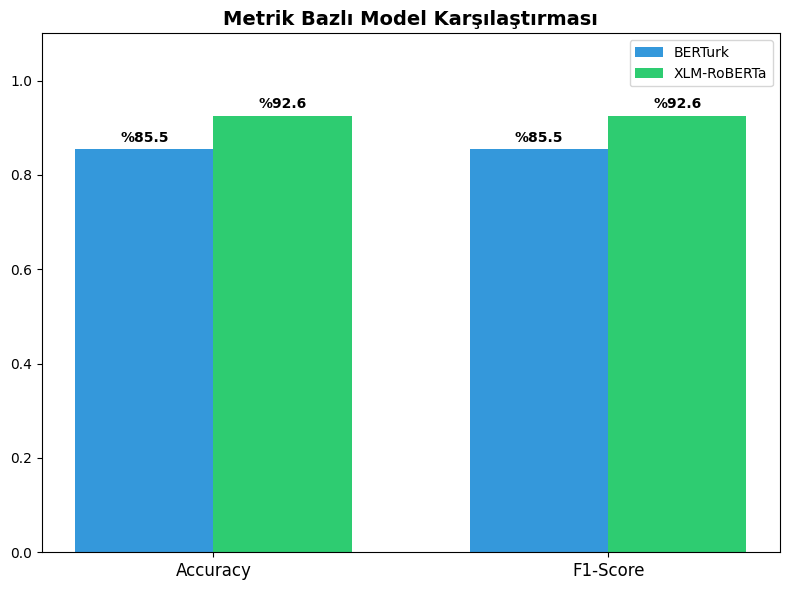

Accuracy -> BERTurk: %85.5 | XLM-RoBERTa: %92.6
F1-Score -> BERTurk: %85.5 | XLM-RoBERTa: %92.6


In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Verileri Metrik Bazlı Hazırlama
metrikler = ['Accuracy', 'F1-Score']
bert_skorlar = [results_bert['eval_accuracy'], results_bert['eval_f1']]
xlm_skorlar = [results_xlm['eval_accuracy'], results_xlm['eval_f1']]

x = np.arange(len(metrikler))  # Metriklerin konumu
width = 0.35  # Çubuk genişliği

fig, ax = plt.subplots(figsize=(8, 6))

# Barlar (Metrikler altında modeller yan yana)
bar1 = ax.bar(x - width/2, bert_skorlar, width, label='BERTurk', color='#3498db')
bar2 = ax.bar(x + width/2, xlm_skorlar, width, label='XLM-RoBERTa', color='#2ecc71')

# Eksen ve Grafik Ayarları
ax.set_title('Metrik Bazlı Model Karşılaştırması', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrikler, fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend()

# Değerleri barların üzerine yazma fonksiyonu
def deger_yaz(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'%{height*100:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

deger_yaz(bar1)
deger_yaz(bar2)

plt.tight_layout()
plt.show()

# Sayısal özet
print(f"Accuracy -> BERTurk: %{bert_skorlar[0]*100:.1f} | XLM-RoBERTa: %{xlm_skorlar[0]*100:.1f}")
print(f"F1-Score -> BERTurk: %{bert_skorlar[1]*100:.1f} | XLM-RoBERTa: %{xlm_skorlar[1]*100:.1f}")

#Gradio

In [ ]:
# Gerekli kütüphaneyi kuralım
!pip install -q gradio

import gradio as gr
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# --- 1. AYARLAR VE MODEL YÜKLEME ---
MODEL_PATH = "./best_bert_model"

# Cihaz seçimi (GPU varsa kullan, yoksa CPU. Tahmin için CPU da yeterlidir.)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Tahmin cihazı: {device}")

print(f"Model yükleniyor: {MODEL_PATH}...")
# Tokenizer ve Modeli kayıtlı klasörden yüklüyoruz
tokenizer_final = AutoTokenizer.from_pretrained(MODEL_PATH)
model_final = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

# Modeli değerlendirme moduna al ve cihaza taşı
model_final.eval()
model_final.to(device)
print("Model başarıyla yüklendi ve hazır!")


# --- 2. TAHMİN FONKSİYONU ---
def duygu_analizi_yap(metin):
    """Gradio arayüzünden gelen metni alır, işler ve olasılıkları döndürür."""

    # a) Temizleme (Daha önce tanımladığınız fonksiyonu kullanıyoruz)
    # UYARI: 'veri_temizleme' fonksiyonu önceki hücrelerde tanımlanmış olmalıdır.
    try:
        temiz_metin = veri_temizleme(metin)
    except NameError:
         return {"Hata": "veri_temizleme fonksiyonu bulunamadı. Lütfen önceki hücreleri çalıştırın."}

    # Boş metin kontrolü
    if not temiz_metin.strip():
        return {"Uyarı": "Lütfen geçerli, dolu bir metin giriniz."}

    # b) Tokenization (Eğitimdeki max_length=256 ile aynı olmalı)
    inputs = tokenizer_final(
        temiz_metin,
        return_tensors="pt", # PyTorch tensoru olarak döndür
        truncation=True,
        padding=True,
        max_length=256
    )

    # Girdileri modele uygun cihaza taşıyoruz
    inputs = {key: val.to(device) for key, val in inputs.items()}

    # c) Model Tahmini
    with torch.no_grad(): # Gradyan hesaplamayı kapat (Hız için)
        outputs = model_final(**inputs)

    # d) Olasılıkları Hesaplama (Logits -> Softmax)
    logits = outputs.logits
    probs = F.softmax(logits, dim=1).squeeze().cpu().numpy()

    # e) Sonucu Gradio formatına çevirme {Etiket: Olasılık}
    # İkili sınıflandırma (0: Olumsuz, 1: Olumlu) varsayımıyla:
    labels = ["OLUMSUZ (Negative) 😞", "OLUMLU (Positive) 😊"]
    sonuc_sozlugu = {labels[i]: float(probs[i]) for i in range(len(labels))}

    return sonuc_sozlugu


# --- 3. GRADIO ARAYÜZÜ (ÖRNEKLER İLE) ---

# Arayüzde görünecek hazır örnek cümleler
ornek_cumleler = [
    ["Bu ürünü gerçekten çok beğendim, harika bir deneyimdi, herkese tavsiye ederim!"],
    ["Kargo rezaletti, ürün elime paramparça ulaştı. Bir daha asla alışveriş yapmam."],
    ["Fiyatına göre idare eder ama çok yüksek beklentiniz olmasın."],
    ["Hizmet çok yavaştı, yemekler soğuk geldi. Tam bir hayal kırıklığı."],
    ["Mükemmel bir film, oyunculuklar şahaneydi. Kesinlikle izleyin."]
]

demo = gr.Interface(
    fn=duygu_analizi_yap, # Çalışacak fonksiyon
    inputs=gr.Textbox(lines=3, placeholder="Analiz etmek istediğiniz yorumu buraya yazın...", label="Giriş Metni"),
    outputs=gr.Label(num_top_classes=2, label="Tahmin Sonucu ve Olasılıklar"),
    title="🤖 BERTurk Duygu Analizi Modeli",
    description="Eğittiğimiz BERT modeli, girdiğiniz metnin olumlu mu olumsuz mu olduğunu tahmin eder. Aşağıdaki örnekleri deneyebilirsiniz.",
    examples=ornek_cumleler, # <-- İSTEDİĞİNİZ ÖRNEKLER BURADA
    theme="soft" # Arayüz teması (soft, default, glass vb.)
)

# Arayüzü başlat
print("Gradio arayüzü başlatılıyor...")
# share=True size 72 saatlik herkese açık bir link verir.
demo.launch(share=True, debug=True)